In [1]:
import pandas as pd
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MultipleLocator
import networkx as nx
from scipy.stats import zscore
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import fdrcorrection
import math

In [2]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'

### Load data

In [ ]:
gnpc_hc = pd.read_csv('./data/GNPC_HC_clinical.csv')

In [5]:
pl_meta_sex_idx = pd.read_csv("./results/gnpc_meta_sex_idx_update.csv")
cell_type_performance = pd.read_csv("./results/Rev_UPDATE_cell_type_performance_gnpc_update_0912.csv")
df_age_gap = pd.read_csv("./results/Rev_UPDATE_gnpc_cell_type_gaps_z_v3.3_by_COHORT_HC_across_cohorts_z.csv")

In [6]:
pl_meta_sex_idx['hc'] = pl_meta_sex_idx['sample_id'].isin(gnpc_hc['sample_id']).astype(int)

In [ ]:
df_age_pred = pd.read_csv("./results/Rev_UPDATE_cell_type_predictions_update.csv")

In [8]:
df_extracted = df_age_pred[['sample_id', 'Chronological_Age', 
                            'Cardiomyocytes_Age', 
                            'Skeletal.myocytes_Age',
                            "Inhibitory.neurons_Age",
                            "Schwann.cells_Age",
                            "Oligodendrocyte.precursor.cells_Age"]]
df_extracted = df_age_pred

In [10]:
merged_df = pd.merge(pl_meta_sex_idx, df_extracted, on='sample_id', how='inner')

In [12]:
df = pl_meta_sex_idx
min_samples = 10
suitable_cohorts = {}
all_cohorts = {}

for diagnosis in ['ad', 'pd', 'als', 'ftd', 'mci_sci']:
    
    suitable_cohorts[diagnosis] = [] 
    all_cohorts[diagnosis] = [] 
    cohorts = df['contributor_code'].unique()
    
    for cohort in cohorts:
        cohort_df = df[df['contributor_code'] == cohort]
        
        disease_count = sum(cohort_df[diagnosis] == 1)
        hc_count = sum(cohort_df['hc'] == 1)
        
        if disease_count >= min_samples and hc_count >= min_samples:
            suitable_cohorts[diagnosis].append(cohort)
            
        if disease_count > 0:
            all_cohorts[diagnosis].append(cohort)

suitable_cohorts

{'ad': ['A', 'C', 'D', 'F', 'G', 'I', 'J', 'L', 'Q', 'R'],
 'pd': ['C', 'F', 'J', 'L', 'Q', 'R'],
 'als': ['M'],
 'ftd': ['C', 'F', 'I', 'N', 'Q'],
 'mci_sci': ['A', 'B', 'C', 'D', 'G', 'I', 'J', 'N', 'P', 'Q', 'R']}

In [13]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'FreeSans', 'Tahoma']

### Chronological age distribution across neurodegeneration diseases

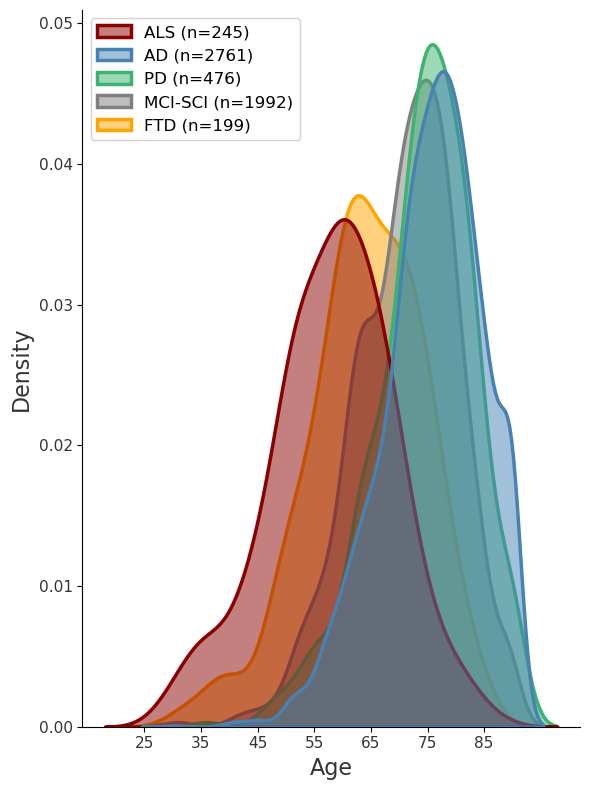

In [ ]:
filtered_data = pl_meta_sex_idx 

plt.figure(figsize=(6, 8))

conditions = ['ftd', 'mci_sci', 'pd',  'als', 'ad']
condition_names = ['FTD', 'MCI-SCI', 'PD', 'ALS', 'AD']
colors = ['orange', 'gray', 'mediumseagreen', 'darkred', 'steelblue']
    
# Create the density (KDE) plot for each condition using only suitable cohorts
for i, condition in enumerate(conditions):
    # Filter for rows that satisfy the condition and come from a suitable cohort
    age_data = filtered_data.loc[
        (filtered_data[condition] == 1) & 
        (filtered_data['contributor_code'].isin(suitable_cohorts[condition])),
        'age_at_visit'
    ]
    
    # Count samples for the legend label
    count = len(age_data)
    
    # Plot the KDE with desired styling
    sns.kdeplot(age_data, 
                color=colors[i], 
                label=f'{condition_names[i]} (n={count})',
                linewidth=2.5,
                alpha=0.5,
                fill=True)

plt.xlabel('Age', fontsize=16,color='#333333')
plt.ylabel('Density', fontsize=16, color='#333333')
plt.title('', fontsize=16, fontweight='bold', color='#333333', pad=20)
plt.xticks(fontsize=11, color='#333333')
plt.yticks(fontsize=11, color='#333333')
plt.xticks([25, 35,45,55, 65, 75,85])

handles, labels = plt.gca().get_legend_handles_labels()

# Create a dictionary mapping condition names to (handle, label)
legend_dict = {}
for h, l in zip(handles, labels):
    # Assuming the first word in the label is the condition name
    name = l.split()[0].upper()
    legend_dict[name] = (h, l)

# Desired legend order by name
desired_order = ['ALS', 'AD', 'PD', 'MCI-SCI', 'FTD']

# Build new lists for handles and labels in the desired order
new_handles = [legend_dict[name][0] for name in desired_order if name in legend_dict]
new_labels  = [legend_dict[name][1] for name in desired_order if name in legend_dict]

plt.legend(new_handles, new_labels, fontsize=12, frameon=True, framealpha=0.9,
           edgecolor='#cccccc', loc='upper left')
ax = plt.gca()
ax.set_facecolor('white')
sns.despine()

plt.tight_layout()

filename = './Rev_results/age_distribution_disease'
plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{filename}.svg", dpi=300, bbox_inches='tight', format='svg')
plt.savefig(f"{filename}.pdf", dpi=300, bbox_inches='tight', format='pdf')

plt.show()


In [ ]:
# Calculate and print age statistics for each condition
print("\nAge Statistics by Condition:")
print("Condition | n    | Min   | Max   | Median  | Mean    | SD")
print("-" * 65)

for i, condition in enumerate(conditions):
    # Filter for rows that satisfy the condition and come from a suitable cohort
    age_data = filtered_data.loc[
        (filtered_data[condition] == 1) & 
        (filtered_data['contributor_code'].isin(suitable_cohorts[condition])),
        'age_at_visit'
    ]
    
    # Calculate statistics
    count = len(age_data)
    minimum = age_data.min()
    maximum = age_data.max()
    median = age_data.median()
    mean = age_data.mean()
    std = age_data.std()
    
    print(f"{condition_names[i]:<10}| {count:<5}| {minimum:.3f} | {maximum:.3f} | {median:.3f}  | {mean:.3f} | {std:.3f}")


Age Statistics by Condition:
Condition | n    | Min   | Max   | Median  | Mean    | SD
-----------------------------------------------------------------
FTD       | 199  | 32.000 | 84.000 | 64.000  | 63.960 | 10.139
MCI-SCI   | 1992 | 28.000 | 90.000 | 72.000  | 71.115 | 9.108
PD        | 476  | 36.000 | 90.000 | 75.000  | 74.319 | 8.837
ALS       | 245  | 29.000 | 87.000 | 59.000  | 58.118 | 10.935
AD        | 2761 | 30.000 | 90.000 | 77.000  | 75.792 | 8.834


### Biological age distribution across neurodegeneration diseases 

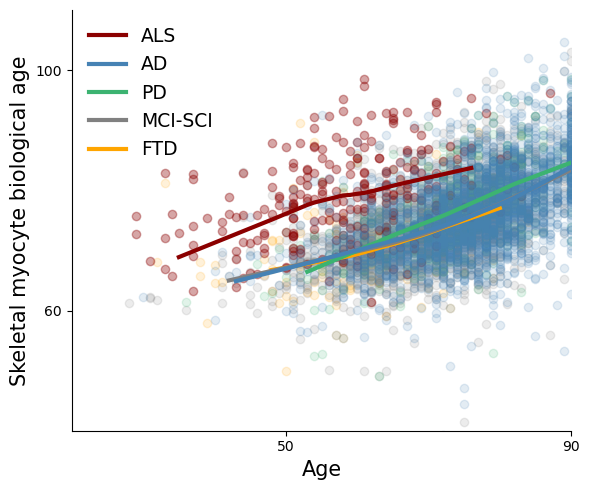

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.lines as mlines

# Define the cell type to analyze
cell_type_select = 'Skeletal.myocytes_Age'

filtered_df = merged_df

conditions = ['ftd', 'mci_sci', 'pd', 'als', 'ad']
condition_names = ['FTD', 'MCI-SCI', 'PD', 'ALS', 'AD']
colors = ['orange', 'gray', 'mediumseagreen', 'darkred', 'steelblue']

# Define density threshold for LOWESS curves
threshold = 10

plt.figure(figsize=(6, 5))

# Dictionary to store legend label text for each condition
legend_info = {}

# Loop over each condition
for cond, cond_name, color in zip(conditions, condition_names, colors):
    scatter_alpha = 0.35 if cond_name == 'ALS' else 0.15

    # Filter patients for the current condition using only the suitable cohorts
    cond_patients = filtered_df[
        (filtered_df[cond] == 1) & 
        (filtered_df['contributor_code'].isin(suitable_cohorts[cond]))
    ]
    n_points = len(cond_patients)
    
    legend_info[cond_name] = cond_name #f'{cond_name} (n={n_points})'
    
    # Scatter plot for the current condition (no legend labels here)
    plt.scatter(
        cond_patients['Chronological_Age'], 
        cond_patients[cell_type_select],
        alpha=scatter_alpha, 
        color=color, 
        label=''  
    )
    
    # Skip LOWESS curve if there are too few points
    if n_points < 10:
        continue
    
    # Sort the data by Chronological_Age for LOWESS processing
    cond_sorted = cond_patients.sort_values('Chronological_Age')
    window_size = (cond_sorted['Chronological_Age'].max() - cond_sorted['Chronological_Age'].min()) / 10
    x_values = cond_sorted['Chronological_Age'].values
    
    # Identify regions with sufficient data density
    dense_regions = []
    for x in x_values:
        nearby_points = np.sum((x_values >= x - window_size/2) & (x_values <= x + window_size/2))
        if nearby_points >= threshold:
            dense_regions.append(x)
    
    if dense_regions:
        dense_cond = cond_sorted[cond_sorted['Chronological_Age'].isin(dense_regions)]
        if len(dense_cond) >= 10:
            lowess_result = lowess(
                dense_cond[cell_type_select], 
                dense_cond['Chronological_Age'], 
                frac=2/3
            )
            plt.plot(lowess_result[:, 0], lowess_result[:, 1], color=color, linewidth=3)

# Format the display name for the y-axis label
display_name = cell_type_select.replace('.', ' ').replace('_Age', '')

plt.xlabel('Age', fontsize=15)
plt.ylabel('Skeletal myocyte biological age', fontsize=15)
plt.xticks([50, 90], fontsize=10)
plt.yticks([60, 100], fontsize=10)
plt.ylim(40, 110)
plt.xlim(min(filtered_df['Chronological_Age']), max(filtered_df['Chronological_Age']))

desired_order = ['ALS', 'AD', 'PD', 'MCI-SCI', 'FTD']

legend_dict = {}
for cond_name, color in zip(condition_names, colors):
    legend_dict[cond_name] = mlines.Line2D([], [], color=color, linewidth=3, label=legend_info[cond_name])

new_handles = [legend_dict[name] for name in desired_order if name in legend_dict]
plt.legend(new_handles, [handle.get_label() for handle in new_handles],
           fontsize=13.5, frameon=False, loc='upper left')

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

filename = './Rev_results/age_skeletal_myocyte'
plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{filename}.svg", dpi=300, bbox_inches='tight', format='svg')
plt.savefig(f"{filename}.pdf", dpi=300, bbox_inches='tight', format='pdf')

plt.show()


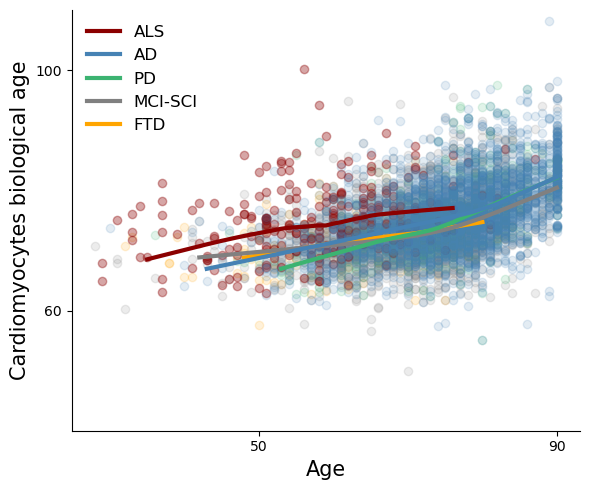

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.lines as mlines

# Define the cell type to analyze
cell_type_select = 'Cardiomyocytes_Age'

filtered_df = merged_df

conditions = ['ftd', 'mci_sci', 'pd', 'als', 'ad']
condition_names = ['FTD', 'MCI-SCI', 'PD', 'ALS', 'AD']
colors = ['orange', 'gray', 'mediumseagreen', 'darkred', 'steelblue']

threshold = 10
plt.figure(figsize=(6, 5))

legend_info = {}

# Loop over each condition
for cond, cond_name, color in zip(conditions, condition_names, colors):
    scatter_alpha = 0.35 if cond_name == 'ALS' else 0.15

    # Filter patients for the current condition using only the suitable cohorts
    cond_patients = filtered_df[
        (filtered_df[cond] == 1) & 
        (filtered_df['contributor_code'].isin(suitable_cohorts[cond]))
    ]
    n_points = len(cond_patients)
    
    legend_info[cond_name] = cond_name #f'{cond_name} (n={n_points})'
    
    # Scatter plot for the current condition (no legend labels here)
    plt.scatter(
        cond_patients['Chronological_Age'], 
        cond_patients[cell_type_select],
        alpha=scatter_alpha, 
        color=color, 
        label=''  
    )
    
    # Skip LOWESS curve if there are too few points
    if n_points < 10:
        continue
    
    # Sort the data by Chronological_Age for LOWESS processing
    cond_sorted = cond_patients.sort_values('Chronological_Age')
    window_size = (cond_sorted['Chronological_Age'].max() - cond_sorted['Chronological_Age'].min()) / 10
    x_values = cond_sorted['Chronological_Age'].values
    
    # Identify regions with sufficient data density
    dense_regions = []
    for x in x_values:
        nearby_points = np.sum((x_values >= x - window_size/2) & (x_values <= x + window_size/2))
        if nearby_points >= threshold:
            dense_regions.append(x)
    
    if dense_regions:
        dense_cond = cond_sorted[cond_sorted['Chronological_Age'].isin(dense_regions)]
        if len(dense_cond) >= 10:
            lowess_result = lowess(
                dense_cond[cell_type_select], 
                dense_cond['Chronological_Age'], 
                frac=2/3
            )
            plt.plot(lowess_result[:, 0], lowess_result[:, 1], color=color, linewidth=3)

# Format the display name for the y-axis label
display_name = cell_type_select.replace('.', ' ').replace('_Age', '')

# Add axis labels and set tick marks/limits
plt.xlabel('Age', fontsize=15)
plt.ylabel(f'{display_name} biological age', fontsize=15)
plt.xticks([50, 90], fontsize=10)
plt.yticks([60, 100], fontsize=10)
plt.ylim(40, 110)

desired_order = ['ALS', 'AD', 'PD', 'MCI-SCI', 'FTD']

# Build a dictionary mapping each condition name to a Line2D handle with its color and label.
legend_dict = {}
for cond_name, color in zip(condition_names, colors):
    legend_dict[cond_name] = mlines.Line2D([], [], color=color, linewidth=3, label=legend_info[cond_name])

# Reassemble legend handles in the desired order
new_handles = [legend_dict[name] for name in desired_order if name in legend_dict]
plt.legend(new_handles, [handle.get_label() for handle in new_handles],
           fontsize=12, frameon=False, loc='upper left')

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

filename = './Rev_results/age_cardiomyocyte'
plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{filename}.svg", dpi=300, bbox_inches='tight', format='svg')
plt.savefig(f"{filename}.pdf", dpi=300, bbox_inches='tight', format='pdf')

plt.show()